22:58:57 KST WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

             WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

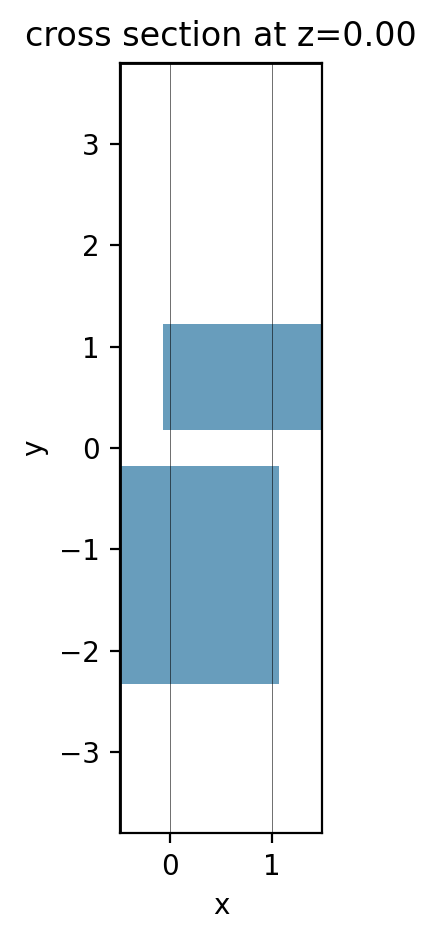

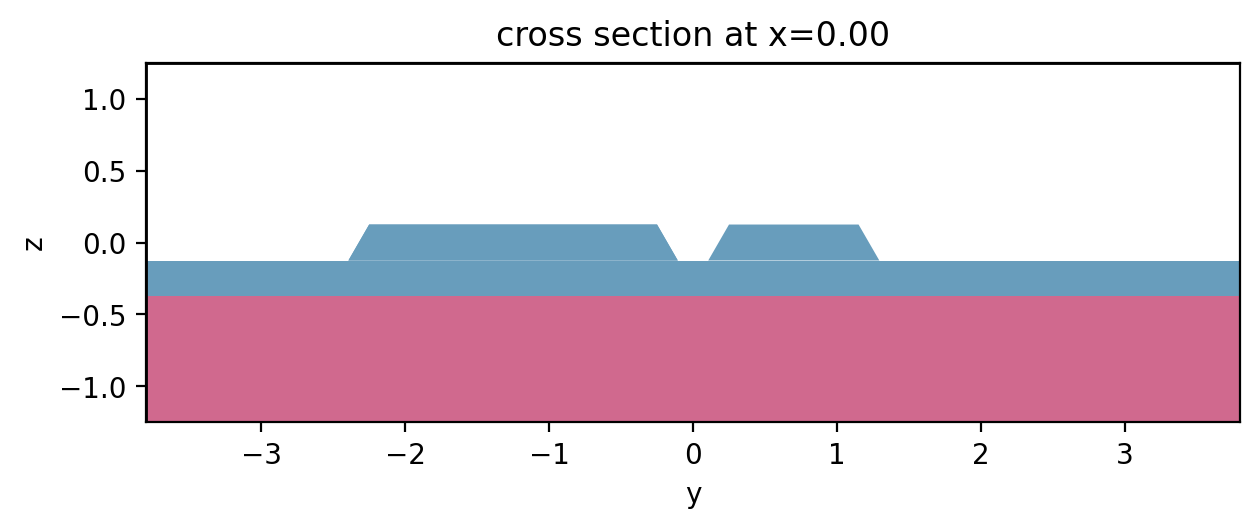

In [126]:
import numpy as np
from matplotlib import pyplot as plt

import tidy3d as td
from tidy3d.plugins import waveguide
import tidy3d.web as web
from tidy3d.plugins.mode import ModeSolver
from tidy3d.plugins.mode.web import run as run_mode_solver

# Simulation wavelength.
wl = 1.55  # Central simulation wavelength (um).
bw = 0.1  # Simulation bandwidth (um).
n_wl = 21  # Number of wavelength points within the bandwidth.
# feat
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])

# material libary
eff_inf = 100
n_sio2 = 1.444  # silicon oxide refractive index at 1550 nm
sio2 = td.Medium(permittivity=n_sio2**2)
air = td.Medium(permittivity=1)



ln_no_coeffs = [(2.6734, 0.01764), (1.2290, 0.05914), (12.614, 474.60)]
ln_ne_coeffs = [(2.6734, 0.01764),  (1.2290, 0.05914),  (12.614, 474.60)]
ln_no= td.Sellmeier(coeffs=ln_no_coeffs)
ln_ne= td.Sellmeier(coeffs=ln_ne_coeffs)

ln = td.AnisotropicMedium(xx=ln_ne, yy=ln_no, zz=ln_no)


Hc=0.25
Hs=0.5-0.25

l=1
w1=0.9
w2=2
radius=80
length_st=600
gap=0.5
radius_wg=radius+w2/2+w1/2+gap

sidewall_angle=(90-60)*np.pi/180
length_buffer=0.5
size_y=w2*2+gap+wl*2
size_x=length_buffer*2+l

vertices1 =[(0,gap/2),(0,gap/2+w1),(l,gap/2+w1),(l,gap/2)]
vertices2 =[(0,-gap/2),(0,-gap/2-w2),(l,-gap/2-w2),(l,-gap/2)]
wg_top = td.Structure(geometry=td.PolySlab(vertices=vertices1, axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"), medium=ln)
wg_bot = td.Structure(geometry=td.PolySlab(vertices=vertices2, axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"), medium=ln)



# ln input port for outer excitation
ln_wg1 = td.Structure(
    geometry=td.PolySlab(vertices=[(-eff_inf,gap/2+w1),(0,gap/2+w1),(0,gap/2),(-eff_inf,gap/2)], axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"),
    medium=ln,
)
ln_wg2 = td.Structure(
    geometry=td.PolySlab(vertices=[(l,-gap/2),(l,-gap/2-w2),(eff_inf,-gap/2-w2),(eff_inf,-gap/2)], axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"),
    medium=ln,
)

# ln input port for inner excitation
ln_wg12 = td.Structure(
    geometry=td.PolySlab(vertices=[(l,gap/2+w1),(eff_inf,gap/2+w1),(eff_inf,gap/2),(l,gap/2)], axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"),
    medium=ln,
)
ln_wg22 = td.Structure(
    geometry=td.PolySlab(vertices=[(0,-gap/2),(0,-gap/2-w2),(-eff_inf,-gap/2-w2),(-eff_inf,-gap/2)], axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=sidewall_angle,reference_plane="top"),
    medium=ln,
)



# ln slab
ln_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -size_y/2, -Hc/2-Hs),
        rmax=(eff_inf, size_y/2, -Hc/2),
    ),
    medium=ln,
)


# sio2 slab
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -size_y/2, -eff_inf),
        rmax=(eff_inf, size_y/2, -Hc/2-Hs),
    ),
    medium=sio2,
)


Structures=[wg_top,wg_bot,ln_wg1,ln_wg2,ln_substrate,sio2_substrate]
Structures2=[wg_top,wg_bot,ln_wg12,ln_wg22,ln_substrate,sio2_substrate]





eme_grid_spec = td.EMEExplicitGrid(
    boundaries=[0, l],
    mode_specs=[
        td.EMEModeSpec(num_modes=2,bend_radius=-(radius+gap/2+w2/2),bend_axis=1),
        td.EMEModeSpec(num_modes=4,bend_radius=(radius+gap/2+w2/2),bend_axis=1),
        td.EMEModeSpec(num_modes=2,bend_radius=(radius+gap/2+w2/2),bend_axis=1)
    ]
)


eme_field_mon = td.EMEFieldMonitor(
    name="field", 
    size=(td.inf, td.inf,0)
)

lengths = np.linspace(l, 80*l, 100)
angle_set=lengths/radius*180/np.pi

eme_sim = td.EMESimulation(
    center=(l/2, 0, 0),
    size=(size_x, size_y, Hc+Hs+2),
    structures=Structures,
    medium=air,
    symmetry=(0, 0, 0),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15,wavelength= wl),
    monitors=[eme_field_mon],
    eme_grid_spec=eme_grid_spec,
    freqs=freq,
    axis=0,
    port_offsets=(0, 0),
    sweep_spec=td.EMELengthSweep(scale_factors=list(lengths / l))
)

eme_sim2 = td.EMESimulation(
    center=(l/2, 0, 0),
    size=(size_x, size_y, Hc+Hs+2),
    structures=Structures2,
    medium=air,
    symmetry=(0, 0, 0),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15,wavelength= wl),
    monitors=[eme_field_mon],
    eme_grid_spec=eme_grid_spec,
    freqs=freq,
    axis=0,
    port_offsets=(0, 0),
    sweep_spec=td.EMELengthSweep(scale_factors=list(lengths / l))
)


_ = eme_sim2.plot(z=0, monitor_alpha=0)
plt.show()

_ = eme_sim2.plot(x=0, monitor_alpha=0)
plt.show()

Now we run the simulation.

22:59:00 KST WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

             WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

22:59:06 KST WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

             WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

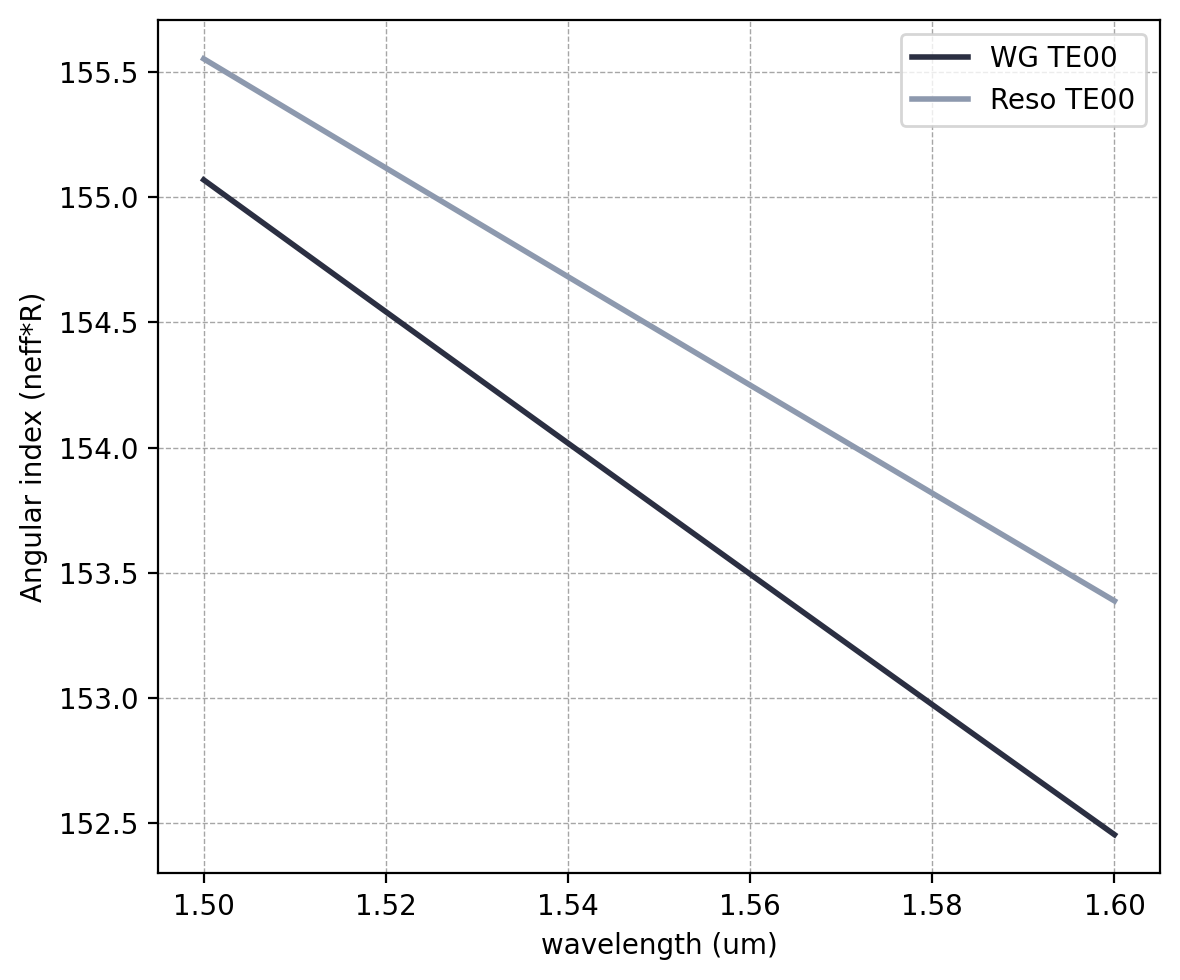

In [127]:
#checking mode profile
"""
num_modes=2
source_plane2 = td.Box(center=[l+length_buffer/2, -gap/2-w2/2, 0], size=[0, 3, 2])
mode_spec = td.ModeSpec(num_modes=num_modes, bend_radius=-radius, bend_axis=1)
ms2 = ModeSolver(simulation=eme_sim, plane=source_plane2, freqs=freq, mode_spec=mode_spec)
modes_reso = ms2.solve()
f, axes = plt.subplots(num_modes, 3, tight_layout=True, figsize=(15, 12))
for axe, mode_index in zip(axes, range(num_modes)):
    for ax, field_name in zip(axe, ("Ex", "Ey", "Ez")):
        ms2.plot_field(field_name, "abs", f=freq, mode_index=mode_index, ax=ax)
plt.show()
"""


# Modal source plane
source_plane1 = td.Box(center=[-length_buffer/2, gap/2+w1/2, 0], size=[0, 3, 2])
source_plane2 = td.Box(center=[l+length_buffer/2, -gap/2-w2/2, 0], size=[0, 3, 2])

num_modes = 1
# NB: negative radius since the plane position is at y=-radius
mode_spec = td.ModeSpec(num_modes=num_modes, bend_radius=radius_wg, bend_axis=1)
ms1 = ModeSolver(simulation=eme_sim, plane=source_plane1, freqs=freqs, mode_spec=mode_spec)

modes_wg = ms1.solve()

mode_spec = td.ModeSpec(num_modes=num_modes, bend_radius=radius, bend_axis=1)
ms2 = ModeSolver(simulation=eme_sim, plane=source_plane2, freqs=freqs, mode_spec=mode_spec)

modes_reso = ms2.solve()


#mode_data = run_mode_solver(mode_solver)
# Plot the mode effective index.
m_eff_wg = modes_wg.n_eff.values.squeeze()*radius_wg
m_eff_r = modes_reso.n_eff.values.squeeze()*radius
fig, ax = plt.subplots(1, 1, figsize=(6, 5), tight_layout=True)
y=[m_eff_wg,m_eff_r]
x=wl_range
%config InlineBackend.figure_format = 'retina'
labels = ["WG TE00", "Reso TE00"]
colors = ["#2B2F42", "#8D99AE", "#EF233C"]
for i, label in enumerate(labels):
    # Line
    ax.plot(x, y[i], label=label, color=colors[i], linewidth=2)

ax.set_xlabel("wavelength (um)")
ax.set_ylabel("Angular index (neff*R)")
ax.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()



In [128]:
eme_sim_data = web.run(eme_sim, task_name="pulley")
eme_sim_data2 = web.run(eme_sim2, task_name="pulley")

22:59:40 KST Created task 'pulley' with task_id                                 
             'eme-c619acdf-c0a5-4dc1-8551-dff4d911ba44' and task_type 'EME'.

             Tidy3D's EME solver is currently in the beta stage. Cost of EME    
             simulations is subject to change in the future.

/Users/hwanghyeon/pattern/tidy/lib/python3.11/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

22:59:43 KST status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

23:00:43 KST status = success

23:00:46 KST loading simulation from simulation_data.hdf5

             WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

             WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

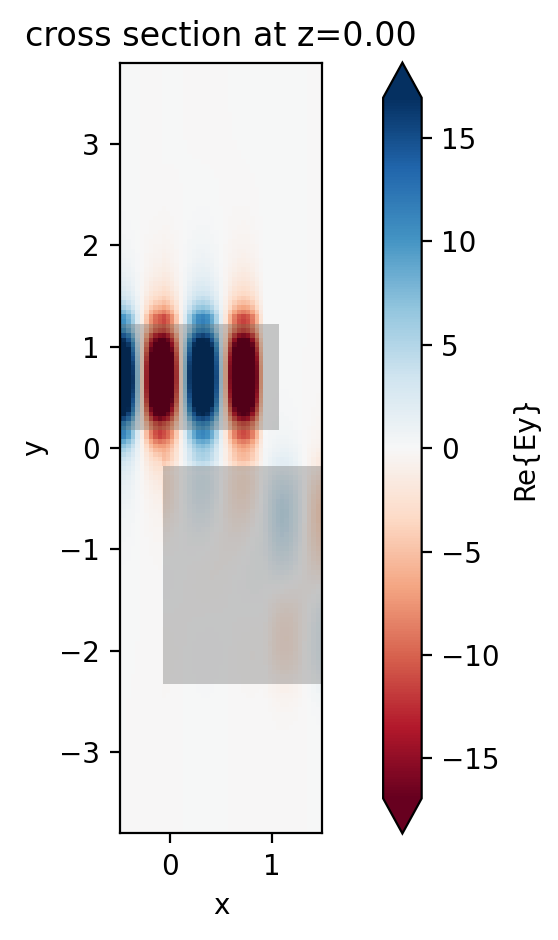

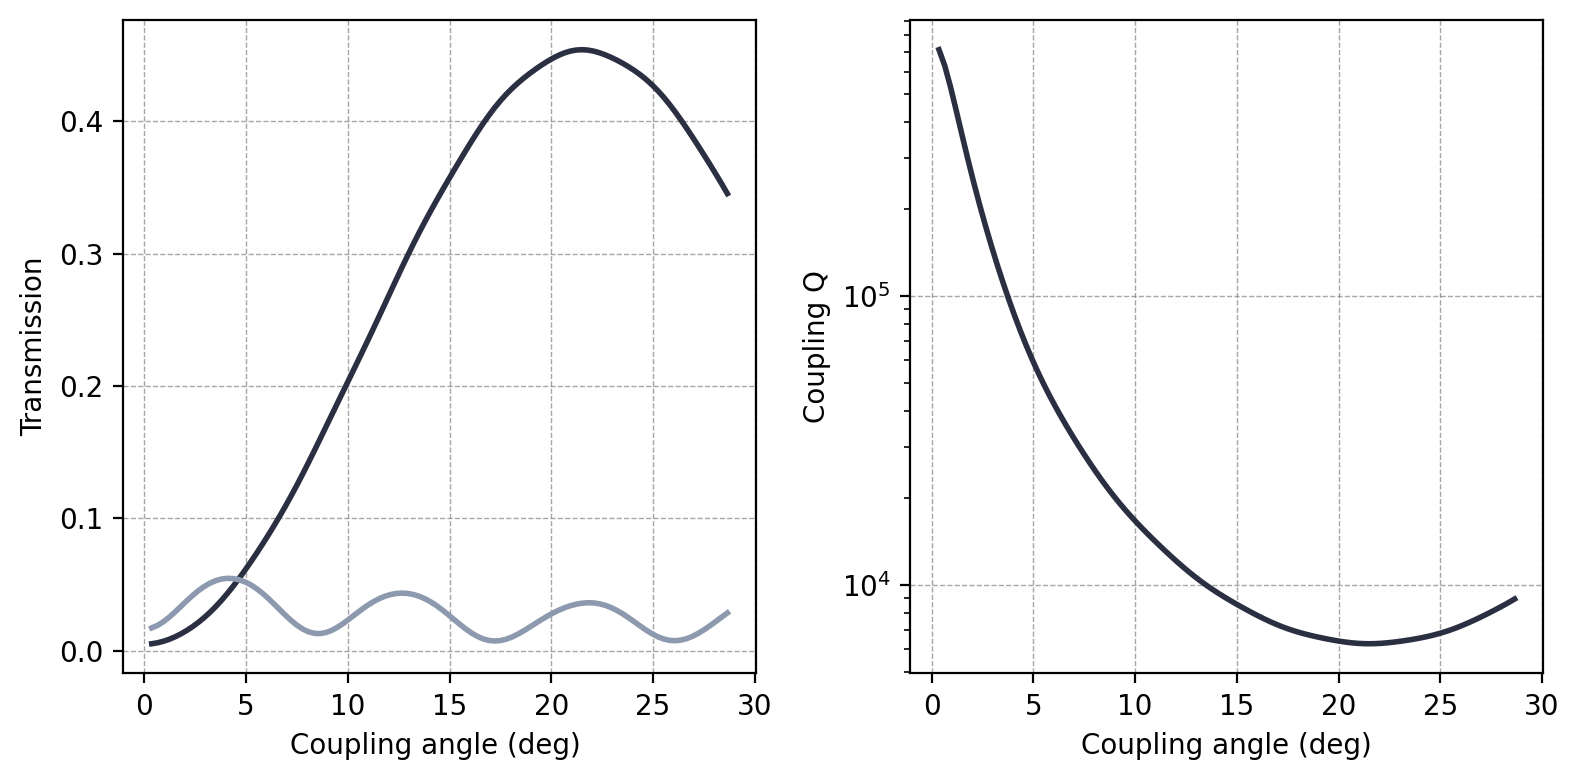

In [129]:
eme_sim_data.plot_field("field", "Ey", eme_port_index=0, mode_index=0)
plt.show()

transmission = eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=0).abs**2
transmission1 = eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=1, f=0).abs**2
transmissionb = eme_sim_data2.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=0).abs**2
transmission1b = eme_sim_data2.smatrix.S21.isel(mode_index_in=0, mode_index_out=1, f=0).abs**2

transmission_set=[transmission,transmission1,transmissionb,transmission1b]
nreso_set=modes_reso.n_eff.values.squeeze()
tr=2*np.pi*radius/3.14e8*nreso_set[0]/1e6 # cavity travelling time
Qc_set=-tr*2*np.pi*freq/np.log(1-transmission)
#plt.plot(lengths, transmission)
colors = ["#2B2F42", "#8D99AE", "#EF233C"]
colors = ["#2B2F42", "#8D99AE", "#2B2F42", "#8D99AE"]
labdel=['TE00','TE10','TE00b','TE10b']
fig, ax = plt.subplots(1, 2, figsize=(8, 4), tight_layout=True)

# angle_set/2 is theta in our lab's rule. from center to theta
for i, label in enumerate(labels):
    # Line
    ax[0].plot(angle_set/2, transmission_set[i], label=label, color=colors[i], linewidth=2)


ax[0].set_xlabel('Coupling angle (deg) ')
ax[0].set_ylabel('Transmission')
ax[0].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax[1].plot(angle_set/2, Qc_set,color=colors[0],linewidth=2)
ax[1].set_xlabel('Coupling angle (deg)')
ax[1].set_ylabel('Coupling Q')
ax[1].set_yscale('log')
ax[1].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()








We can plot the transmission as a function of the length of the coupling region.

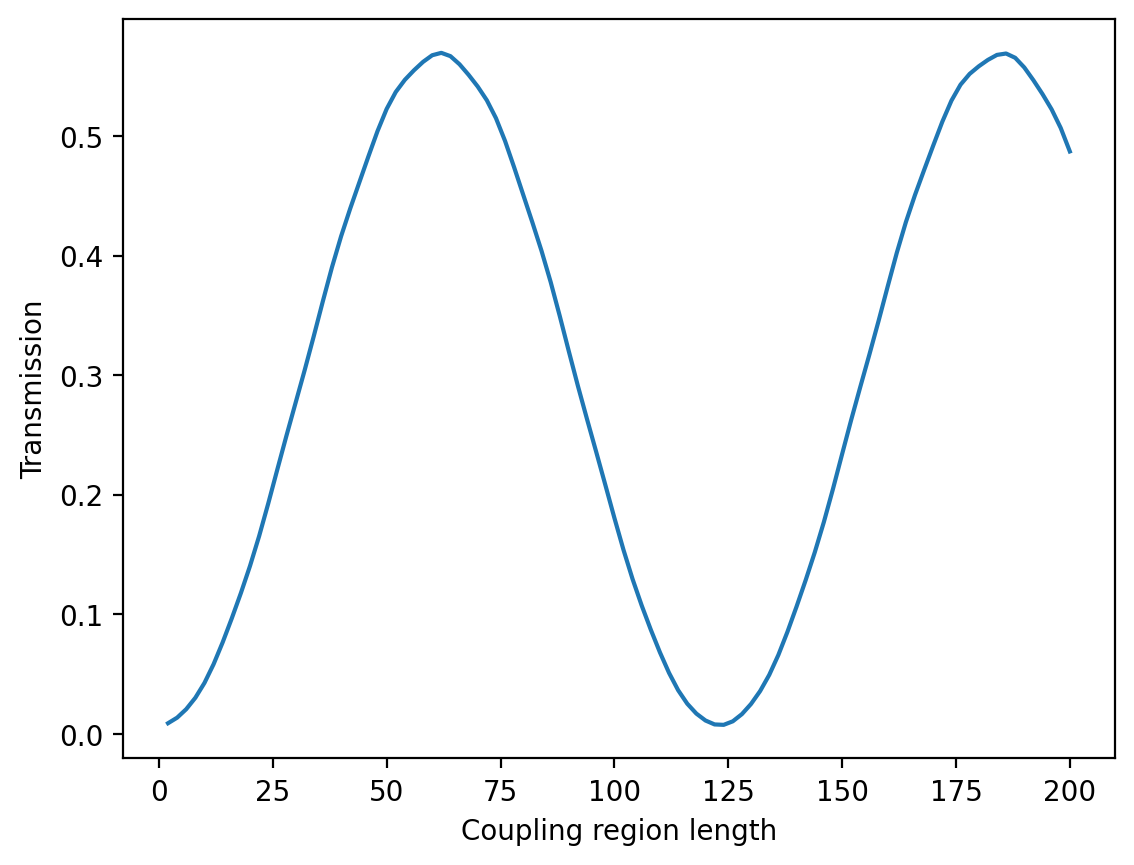

In [78]:
transmission = eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=0).abs**2
plt.plot(lengths, transmission)
plt.xlabel('Coupling region length')
plt.ylabel('Transmission')
plt.show()